In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.integrate import quad
from scipy.optimize import root_scalar
import warnings
from joblib import Parallel, delayed
from scipy.integrate import IntegrationWarning

In [50]:
# Suppress integration warnings for clean console output
warnings.filterwarnings("ignore", category=IntegrationWarning)

def calc_r_mu(mu, X_obs, c):
    """
    Computes the exact conditional survival function r_mu(X_obs, c) 
    using the p-value thinning weight function w_c(q).
    """
    z_jump = norm.isf(c**2)
    
    # --- Denominator ---
    den_lower = 0.0
    lb = mu - 15
    ub = min(z_jump, mu + 15)
    if lb < ub:
        den_lower, _ = quad(
            lambda z: 0.5 * c * norm.pdf(z - mu) / np.sqrt(norm.sf(z)), 
            lb, ub, epsabs=1e-4, epsrel=1e-4
        )
    den_upper = norm.sf(z_jump - mu)
    den = den_lower + den_upper
    
    if den <= 0: 
        return 0.0
    
    # --- Numerator ---
    num = 0.0
    if X_obs < z_jump:
        num_lower = 0.0
        lb_num = max(X_obs, mu - 15)
        if lb_num < ub:
            num_lower, _ = quad(
                lambda z: 0.5 * c * norm.pdf(z - mu) / np.sqrt(norm.sf(z)), 
                lb_num, ub, epsabs=1e-4, epsrel=1e-4
            )
        num = num_lower + den_upper
    else:
        num = norm.sf(X_obs - mu)
        
    return num / den

def calc_r_cond_mu(mu, X_obs, c_cond):
    """
    Truncated Normal survival function for the standard Selective Inference approach.
    Uses log survival functions to avoid extreme underflow for large positive gaps.
    """
    log_num = norm.logsf(X_obs - mu)
    log_den = norm.logsf(c_cond - mu)
    return np.exp(log_num - log_den)

def safe_root(f, X_obs):
    """
    Robust root-finder that expands the bracket until it detects the bounds.
    """
    for span in [15, 50, 200]:
        a, b = X_obs - span, X_obs + span
        try:
            fa, fb = f(a), f(b)
            if np.sign(fa) != np.sign(fb) and not np.isnan(fa) and not np.isnan(fb):
                res = root_scalar(f, bracket=[a, b], method='brentq')
                if res.converged:
                    return res.root
        except Exception:
            pass
    return np.nan

def get_p_thinning_ci(X_obs, c, alpha=0.05):
    f_L = lambda mu: calc_r_mu(mu, X_obs, c) - alpha/2
    f_U = lambda mu: calc_r_mu(mu, X_obs, c) - (1 - alpha/2)
    
    mu_L = safe_root(f_L, X_obs)
    mu_U = safe_root(f_U, X_obs)
    
    # Cap width if root failed
    if np.isnan(mu_L): mu_L = X_obs - 50
    if np.isnan(mu_U): mu_U = X_obs + 50
        
    return mu_L, mu_U

def get_cond_ci(X_obs, c_cond, alpha=0.05):
    f_L = lambda mu: calc_r_cond_mu(mu, X_obs, c_cond) - alpha/2
    f_U = lambda mu: calc_r_cond_mu(mu, X_obs, c_cond) - (1 - alpha/2)
    
    mu_L = safe_root(f_L, X_obs)
    mu_U = safe_root(f_U, X_obs)
    
    if np.isnan(mu_L): mu_L = X_obs - 50
    if np.isnan(mu_U): mu_U = X_obs + 50
    return mu_L, mu_U

In [54]:
def run_single_rep(mu, gap_ratio, N_total, alpha, seed):
    """
    Executes a single replication of the simulation.
    Takes a unique SeedSequence child to guarantee independent random variables.
    """
    rng = np.random.default_rng(seed)
    
    # One-Sided Upper-Tailed Test
    X = rng.normal(0, 1, size=N_total)
    X[0] += mu
    X[1] += mu * gap_ratio
    p = norm.sf(X)

    res = {"p-thinning": {}, "thinning": {}, "csi": {}}

    # --- 1. p-value thinning (Theorem) ---
    Z_rv = rng.uniform(0, 1, size=N_total)
    C = rng.integers(0, 2, size=N_total)
    p1 = np.sqrt(p) * (C + (1 - C) * Z_rv)
    
    sel = np.argmin(p1)
    c_thin = np.sort(p1)[1]
    
    true_mu = mu if sel == 0 else (mu * gap_ratio if sel == 1 else 0.0)
    
    mu_L, mu_U = get_p_thinning_ci(X[sel], c_thin, alpha)
    res["p-thinning"]["coverage"] = (mu_L <= true_mu <= mu_U)
    res["p-thinning"]["width"] = (mu_U - mu_L)

    # --- 2. Data thinning (Gaussian) ---
    eps = rng.normal(0, 1, size=N_total)
    X1 = (X + eps) / np.sqrt(2)
    X2 = (X - eps) / np.sqrt(2)
    
    sel_dt = np.argmax(X1)
    true_mu_dt = mu if sel_dt == 0 else (mu * gap_ratio if sel_dt == 1 else 0.0)
    
    X2_sel = X2[sel_dt]
    z_alpha = norm.isf(alpha / 2)
    dt_L = np.sqrt(2) * X2_sel - np.sqrt(2) * z_alpha
    dt_U = np.sqrt(2) * X2_sel + np.sqrt(2) * z_alpha
    
    res["thinning"]["coverage"] = (dt_L <= true_mu_dt <= dt_U)
    res["thinning"]["width"] = (dt_U - dt_L)

    # --- 3. Conditional (Truncated Gaussian) ---
    sel_cond = np.argmax(X)
    true_mu_cond = mu if sel_cond == 0 else (mu * gap_ratio if sel_cond == 1 else 0.0)
    
    c_cond = np.sort(X)[-2]
    
    cond_L, cond_U = get_cond_ci(X[sel_cond], c_cond, alpha)
    res["csi"]["coverage"] = (cond_L <= true_mu_cond <= cond_U)
    res["csi"]["width"] = (cond_U - cond_L)

    return res

def get_wc_results(N_total, n_reps, mus, gap_ratio, alpha, n_jobs=-1):
    """
    Parallelized evaluation using joblib.
    n_jobs=-1 will use all available CPU cores.
    """
    results = {
        k: {"coverage": [], "width": []}
        for k in ["p-thinning", "thinning", "csi"]
    }
    
    # Properly seed the parallel PRNGs to avoid duplicate random numbers
    ss = np.random.SeedSequence(42)
    
    # Spawn enough independent seeds for every single rep across all mu's
    child_seeds = ss.spawn(len(mus) * n_reps)

    seed_idx = 0
    for mu in mus:
        # Get the slice of seeds for the current mu
        mu_seeds = child_seeds[seed_idx : seed_idx + n_reps]
        seed_idx += n_reps
        
        # Parallelize across the `n_reps` replications
        rep_results = Parallel(n_jobs=n_jobs)(
            delayed(run_single_rep)(mu, gap_ratio, N_total, alpha, seed)
            for seed in mu_seeds
        )
        
        # Aggregate the results from the parallel jobs
        for k in results:
            mean_cov = np.mean([r[k]["coverage"] for r in rep_results])
            mean_width = np.median([r[k]["width"] for r in rep_results])
            results[k]["coverage"].append(mean_cov)
            results[k]["width"].append(mean_width)

    return results

In [56]:
# --- Simulation Parameters ---
# (n_reps can be reduced if you want to test the script execution time quickly)
n_reps = 1000
n_total = 10
mus = np.linspace(0, 4, 5)
alpha = 0.05

results_low = get_wc_results(n_total, n_reps, mus, 0, alpha)
results_med = get_wc_results(n_total, n_reps, mus, 0.5, alpha)
results_high = get_wc_results(n_total, n_reps, mus, 1, alpha)

/var/folders/sd/v_dt5vp17z75wd22155dfr880000gn/T/ipykernel_3084/759751609.py:32: IntegrationWarning: Extremely bad integrand behavior occurs at some points of the
  integration interval.
/var/folders/sd/v_dt5vp17z75wd22155dfr880000gn/T/ipykernel_3084/759751609.py:32: IntegrationWarning: Extremely bad integrand behavior occurs at some points of the
  integration interval.
/var/folders/sd/v_dt5vp17z75wd22155dfr880000gn/T/ipykernel_3084/759751609.py:32: IntegrationWarning: Extremely bad integrand behavior occurs at some points of the
  integration interval.
/var/folders/sd/v_dt5vp17z75wd22155dfr880000gn/T/ipykernel_3084/759751609.py:32: IntegrationWarning: Extremely bad integrand behavior occurs at some points of the
  integration interval.
/var/folders/sd/v_dt5vp17z75wd22155dfr880000gn/T/ipykernel_3084/759751609.py:32: IntegrationWarning: Extremely bad integrand behavior occurs at some points of the
  integration interval.
/var/folders/sd/v_dt5vp17z75wd22155dfr880000gn/T/ipykernel_3084/7

In [ ]:
import pickle
filename = "results/winners_ci.pkl"
with open(filename, "wb") as f:
    pickle.dump(
        {
            "low": results_low,
            "med": results_med,
            "high": results_high
        }, f)

SyntaxError: positional argument follows keyword argument (3441078139.py, line 9)

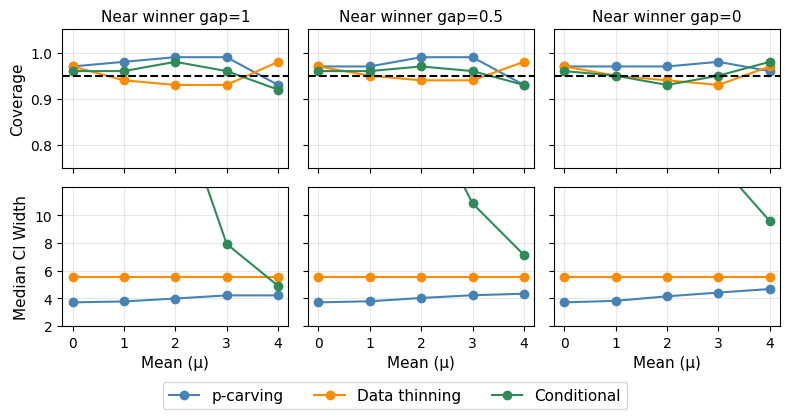

In [53]:
# --- Plotting ---
labels = {
    'p-thinning': 'p-carving',
    'thinning': 'Data thinning',
    'csi': 'Conditional'
}
colors = {
    'p-thinning': 'steelblue',
    'csi': 'seagreen',
    'thinning': 'darkorange'
}

fig, axes = plt.subplots(2, 3, figsize=(8, 4), sharex=True, sharey='row')

# Loop over the 3 gap ratio scenarios
for i, results, n in zip([0, 1, 2], [results_low, results_med, results_high], [0, 0.5, 1]):
    
    # 1. Plot Coverage
    for k in results:
        axes[0, i].plot(mus, results[k]['coverage'], marker='o', label=labels[k], color=colors[k]) 
    
    axes[0, i].grid(True, alpha=0.3)
    axes[0, i].axhline(1 - alpha, color='black', linestyle='--')
    axes[0, i].set_title(f'Near winner gap={1 - n}', fontsize=11)
    axes[0, i].set_ylim(0.75, 1.05)
    
    # 2. Plot CI Width
    for k in results:
        axes[1, i].plot(mus, results[k]['width'], marker='o', label=labels[k], color=colors[k])   
        
    axes[1, i].grid(True, alpha=0.3)
    axes[1, i].set_xlabel('Mean (μ)', fontsize=11)
    axes[1, i].set_ylim(2, 12)  # Cut off infinite explosion for CSI visualization

axes[0, 0].set_ylabel('Coverage', fontsize=11)
axes[1, 0].set_ylabel('Median CI Width', fontsize=11)
axes[1, 0].set_yticks([2, 4, 6, 8, 10])

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.05),
    ncol=3,
    frameon=True,
    fontsize=11
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.17)
plt.savefig('./figures/winners_curse_ci.png', bbox_inches='tight')
plt.show()
